# Nigeria’s Export Structure: Crude Oil vs Non-Oil Exports, Q3 2024 - Q4 2025

This notebook analyses quarterly Nigerian foreign trade data from the National Bureau of Statistics.

This Jupyter Notebook is for International Economy and Financial Markets Individual Report.

Module Code: 7ECON021W.1

Westminster Business School

It extracts data from five quarterly Excel files:

- Q3 2024
- Q4 2024
- Q1 2025
- Q2 2025
- Q3 2025
- Q4 2025

The final chart shows:

- crude oil share of total exports
- non-oil share of total exports
- trade balance

The purpose is to support the report argument that Nigeria’s export structure remains vulnerable despite signs of gradual diversification.

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
folder = Path("/Users/desmondvi/Desktop/0022")

files = {
    "Q3 2024": folder / "Q3_2024.xlsx",
    "Q4 2024": folder / "Q4_2024.xlsx",
    "Q1 2025": folder / "Q1_2025.xlsx",
    "Q2 2025": folder / "Q2_2025.xlsx",
    "Q3 2025": folder / "Q3_2025.xlsx",
    "Q4 2025": folder / "Q4_2025.xlsx",
}

print("Working folder:", folder)
print("Folder exists:", folder.exists())

for quarter, path in files.items():
    print(f"{quarter}: {path.exists()} -> {path}")

Working folder: /Users/desmondvi/Desktop/0022
Folder exists: True
Q3 2024: True -> /Users/desmondvi/Desktop/0022/Q3_2024.xlsx
Q4 2024: True -> /Users/desmondvi/Desktop/0022/Q4_2024.xlsx
Q1 2025: True -> /Users/desmondvi/Desktop/0022/Q1_2025.xlsx
Q2 2025: True -> /Users/desmondvi/Desktop/0022/Q2_2025.xlsx
Q3 2025: True -> /Users/desmondvi/Desktop/0022/Q3_2025.xlsx
Q4 2025: True -> /Users/desmondvi/Desktop/0022/Q4_2025.xlsx


In [3]:
def clean_text(value):
    """
    Clean text from Excel cells.
    """
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value).strip())


def to_number(value):
    """
    Convert Excel cell values to float.
    Handles commas, percent signs and parentheses.
    """
    if pd.isna(value):
        return None

    if isinstance(value, (int, float)):
        return float(value)

    value = str(value).strip()
    value = value.replace(",", "")
    value = value.replace("₦", "")
    value = value.replace("N", "")
    value = value.replace("%", "")
    value = value.replace("(", "-").replace(")", "")

    try:
        return float(value)
    except ValueError:
        return None


def read_table_1_summary(excel_path):
    """
    Read TABLE 1 from NBS Excel file.

    The NBS files often have different numbers of empty columns before the real table.
    This function dynamically finds the 'Imports' column and then treats the two
    columns before it as Year and Period.
    """
    raw = pd.read_excel(excel_path, sheet_name="TABLE 1", header=None)

    header_row = None
    import_col = None

    for i in range(len(raw)):
        row_values = [clean_text(x).lower() for x in raw.iloc[i].tolist()]

        for j, cell in enumerate(row_values):
            row_text = " ".join(row_values)

            if (
                cell == "imports"
                and "exports" in row_text
                and "balance" in row_text
                and "total trade" in row_text
            ):
                header_row = i
                import_col = j
                break

        if header_row is not None:
            break

    if header_row is None or import_col is None:
        raise ValueError(f"Could not find summary header in {excel_path.name}")

    selected_columns = [import_col - 2, import_col - 1] + list(range(import_col, raw.shape[1]))

    headers = ["Year", "Period"] + [
        clean_text(x) for x in raw.iloc[header_row, import_col:].tolist()
    ]

    data = raw.iloc[header_row + 1:, selected_columns].copy()
    data.columns = headers
    data = data.dropna(how="all").reset_index(drop=True)

    data["Year"] = data["Year"].ffill()
    data["Year"] = data["Year"].apply(clean_text)
    data["Period"] = data["Period"].apply(clean_text)

    return data


def extract_selected_quarter(excel_path, quarter_label):
    """
    Extract the exact quarter row, e.g. Q3 2024.
    """
    target_period, target_year = quarter_label.split()

    table = read_table_1_summary(excel_path)

    selected = table[
        (table["Year"] == target_year)
        & (table["Period"] == target_period)
    ]

    if selected.empty:
        print("Available rows:")
        print(table[["Year", "Period"]].tail(30))
        raise ValueError(f"Could not find {quarter_label} in {excel_path.name}")

    return selected.iloc[0]

In [4]:
records = []

for quarter, path in files.items():
    print(f"Processing {quarter}: {path.name}")

    row = extract_selected_quarter(path, quarter)

    imports_million = to_number(row["Imports"])
    exports_million = to_number(row["Exports(fob)"])
    balance_million = to_number(row["Balance"])
    total_trade_million = to_number(row["Total Trade"])
    crude_oil_exports_million = to_number(row["Crude Oil Exports"])
    non_crude_oil_exports_million = to_number(row["Non_Crude Oil Exports"])
    non_oil_exports_million = to_number(row["Non Oils Exports"])
    crude_share = to_number(row["Crude Oil /Total Exports (%)"])
    non_oil_share = to_number(row["Non Oil Export/Total Export(%)"])

    records.append(
        {
            "Quarter": quarter,
            "Imports_NGN_billion": imports_million / 1000,
            "Exports_NGN_billion": exports_million / 1000,
            "Trade_Balance_NGN_billion": balance_million / 1000,
            "Total_Trade_NGN_billion": total_trade_million / 1000,
            "Crude_Oil_Exports_NGN_billion": crude_oil_exports_million / 1000,
            "Non_Crude_Oil_Exports_NGN_billion": non_crude_oil_exports_million / 1000,
            "Non_Oil_Exports_NGN_billion": non_oil_exports_million / 1000,
            "Crude_Oil_Share_of_Exports_pct": crude_share,
            "Non_Oil_Share_of_Exports_pct": non_oil_share,
        }
    )

df = pd.DataFrame(records)
df

Processing Q3 2024: Q3_2024.xlsx
Processing Q4 2024: Q4_2024.xlsx
Processing Q1 2025: Q1_2025.xlsx
Processing Q2 2025: Q2_2025.xlsx
Processing Q3 2025: Q3_2025.xlsx
Processing Q4 2025: Q4_2025.xlsx


,Quarter,Imports_NGN_billion,Exports_NGN_billion,Trade_Balance_NGN_billion,Total_Trade_NGN_billion,Crude_Oil_Exports_NGN_billion,Non_Crude_Oil_Exports_NGN_billion,Non_Oil_Exports_NGN_billion,Crude_Oil_Share_of_Exports_pct,Non_Oil_Share_of_Exports_pct
0,Q3 2024,14674.046798,20486.389946,5812.343148,35160.436744,13406.367224,7080.022722,2501.849926,65.440359,12.212254
1,Q4 2024,16590.505533,20014.329120,3423.823587,36604.834652,13783.003497,6231.325623,2842.522861,68.865678,14.202439
2,Q1 2025,15426.174745,20598.480753,5172.306008,36024.655498,12955.028202,7643.452550,3167.875826,62.893125,15.379172
3,Q2 2025,15286.779407,22750.744240,7463.964833,38037.523646,11965.980580,10784.763660,3045.547303,52.595996,13.386583
4,Q3 2025,16122.981720,22813.567873,6690.586153,38936.549594,12806.776152,10006.791721,2996.620935,56.136665,13.135258
5,Q4 2025,17250.934008,18963.409975,1712.475966,36214.343983,9702.868891,9260.541084,3145.544959,51.166267,16.587444


In [5]:
quarter_order = {
    "Q3 2024": 1,
    "Q4 2024": 2,
    "Q1 2025": 3,
    "Q2 2025": 4,
    "Q3 2025": 5,
    "Q4 2025": 6,
}

df["Order"] = df["Quarter"].map(quarter_order)
df = df.sort_values("Order").drop(columns=["Order"]).reset_index(drop=True)

df["Non_Crude_Oil_Share_of_Exports_pct"] = 100 - df["Crude_Oil_Share_of_Exports_pct"]

df["Export_to_Import_Ratio"] = (
    df["Exports_NGN_billion"] / df["Imports_NGN_billion"]
)

df["Trade_Balance_as_pct_of_Total_Trade"] = (
    df["Trade_Balance_NGN_billion"] / df["Total_Trade_NGN_billion"] * 100
)

df

,Quarter,Imports_NGN_billion,Exports_NGN_billion,Trade_Balance_NGN_billion,Total_Trade_NGN_billion,Crude_Oil_Exports_NGN_billion,Non_Crude_Oil_Exports_NGN_billion,Non_Oil_Exports_NGN_billion,Crude_Oil_Share_of_Exports_pct,Non_Oil_Share_of_Exports_pct,Non_Crude_Oil_Share_of_Exports_pct,Export_to_Import_Ratio,Trade_Balance_as_pct_of_Total_Trade
0,Q3 2024,14674.046798,20486.389946,5812.343148,35160.436744,13406.367224,7080.022722,2501.849926,65.440359,12.212254,34.559641,1.396097,16.530919
1,Q4 2024,16590.505533,20014.329120,3423.823587,36604.834652,13783.003497,6231.325623,2842.522861,68.865678,14.202439,31.134322,1.206372,9.353474
2,Q1 2025,15426.174745,20598.480753,5172.306008,36024.655498,12955.028202,7643.452550,3167.875826,62.893125,15.379172,37.106875,1.335294,14.357683
3,Q2 2025,15286.779407,22750.744240,7463.964833,38037.523646,11965.980580,10784.763660,3045.547303,52.595996,13.386583,47.404004,1.488263,19.622636
4,Q3 2025,16122.981720,22813.567873,6690.586153,38936.549594,12806.776152,10006.791721,2996.620935,56.136665,13.135258,43.863335,1.414972,17.183305
5,Q4 2025,17250.934008,18963.409975,1712.475966,36214.343983,9702.868891,9260.541084,3145.544959,51.166267,16.587444,48.833733,1.099269,4.728723


In [6]:
report_table = df[
    [
        "Quarter",
        "Total_Trade_NGN_billion",
        "Exports_NGN_billion",
        "Imports_NGN_billion",
        "Trade_Balance_NGN_billion",
        "Crude_Oil_Share_of_Exports_pct",
        "Non_Oil_Share_of_Exports_pct",
        "Trade_Balance_as_pct_of_Total_Trade",
    ]
].copy()

report_table

,Quarter,Total_Trade_NGN_billion,Exports_NGN_billion,Imports_NGN_billion,Trade_Balance_NGN_billion,Crude_Oil_Share_of_Exports_pct,Non_Oil_Share_of_Exports_pct,Trade_Balance_as_pct_of_Total_Trade
0,Q3 2024,35160.436744,20486.389946,14674.046798,5812.343148,65.440359,12.212254,16.530919
1,Q4 2024,36604.834652,20014.329120,16590.505533,3423.823587,68.865678,14.202439,9.353474
2,Q1 2025,36024.655498,20598.480753,15426.174745,5172.306008,62.893125,15.379172,14.357683
3,Q2 2025,38037.523646,22750.744240,15286.779407,7463.964833,52.595996,13.386583,19.622636
4,Q3 2025,38936.549594,22813.567873,16122.981720,6690.586153,56.136665,13.135258,17.183305
5,Q4 2025,36214.343983,18963.409975,17250.934008,1712.475966,51.166267,16.587444,4.728723


In [7]:
formatted_table = report_table.copy()

money_cols = [
    "Total_Trade_NGN_billion",
    "Exports_NGN_billion",
    "Imports_NGN_billion",
    "Trade_Balance_NGN_billion",
]

percentage_cols = [
    "Crude_Oil_Share_of_Exports_pct",
    "Non_Oil_Share_of_Exports_pct",
    "Trade_Balance_as_pct_of_Total_Trade",
]

for col in money_cols:
    formatted_table[col] = formatted_table[col].map(lambda x: f"₦{x:,.2f}bn")

for col in percentage_cols:
    formatted_table[col] = formatted_table[col].map(lambda x: f"{x:.2f}%")

formatted_table

,Quarter,Total_Trade_NGN_billion,Exports_NGN_billion,Imports_NGN_billion,Trade_Balance_NGN_billion,Crude_Oil_Share_of_Exports_pct,Non_Oil_Share_of_Exports_pct,Trade_Balance_as_pct_of_Total_Trade
0,Q3 2024,"₦35,160.44bn","₦20,486.39bn","₦14,674.05bn","₦5,812.34bn",65.44%,12.21%,16.53%
1,Q4 2024,"₦36,604.83bn","₦20,014.33bn","₦16,590.51bn","₦3,423.82bn",68.87%,14.20%,9.35%
2,Q1 2025,"₦36,024.66bn","₦20,598.48bn","₦15,426.17bn","₦5,172.31bn",62.89%,15.38%,14.36%
3,Q2 2025,"₦38,037.52bn","₦22,750.74bn","₦15,286.78bn","₦7,463.96bn",52.60%,13.39%,19.62%
4,Q3 2025,"₦38,936.55bn","₦22,813.57bn","₦16,122.98bn","₦6,690.59bn",56.14%,13.14%,17.18%
5,Q4 2025,"₦36,214.34bn","₦18,963.41bn","₦17,250.93bn","₦1,712.48bn",51.17%,16.59%,4.73%


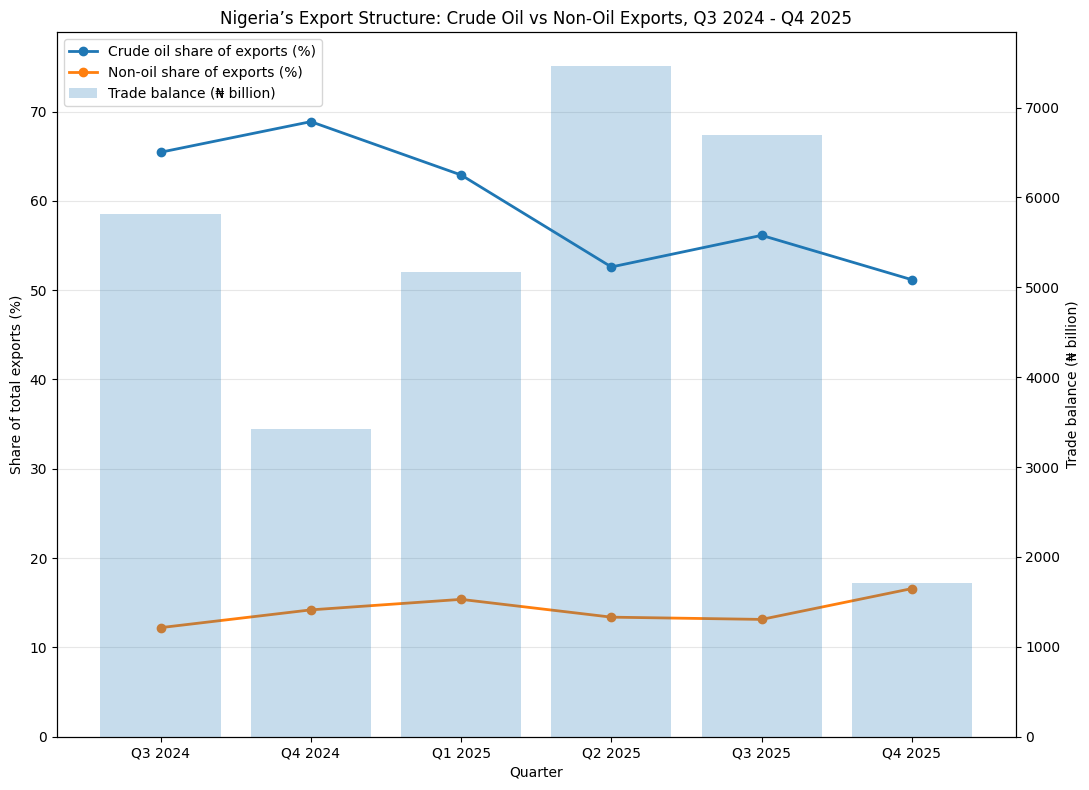

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 8))

ax1.plot(
    df["Quarter"],
    df["Crude_Oil_Share_of_Exports_pct"],
    marker="o",
    linewidth=2,
    label="Crude oil share of exports (%)",
)

ax1.plot(
    df["Quarter"],
    df["Non_Oil_Share_of_Exports_pct"],
    marker="o",
    linewidth=2,
    label="Non-oil share of exports (%)",
)

ax1.set_xlabel("Quarter")
ax1.set_ylabel("Share of total exports (%)")
ax1.set_ylim(0, max(df["Crude_Oil_Share_of_Exports_pct"]) + 10)

ax2 = ax1.twinx()

ax2.bar(
    df["Quarter"],
    df["Trade_Balance_NGN_billion"],
    alpha=0.25,
    label="Trade balance (₦ billion)",
)

ax2.set_ylabel("Trade balance (₦ billion)")

ax1.set_title(
    "Nigeria’s Export Structure: Crude Oil vs Non-Oil Exports, Q3 2024 - Q4 2025"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
)

ax1.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

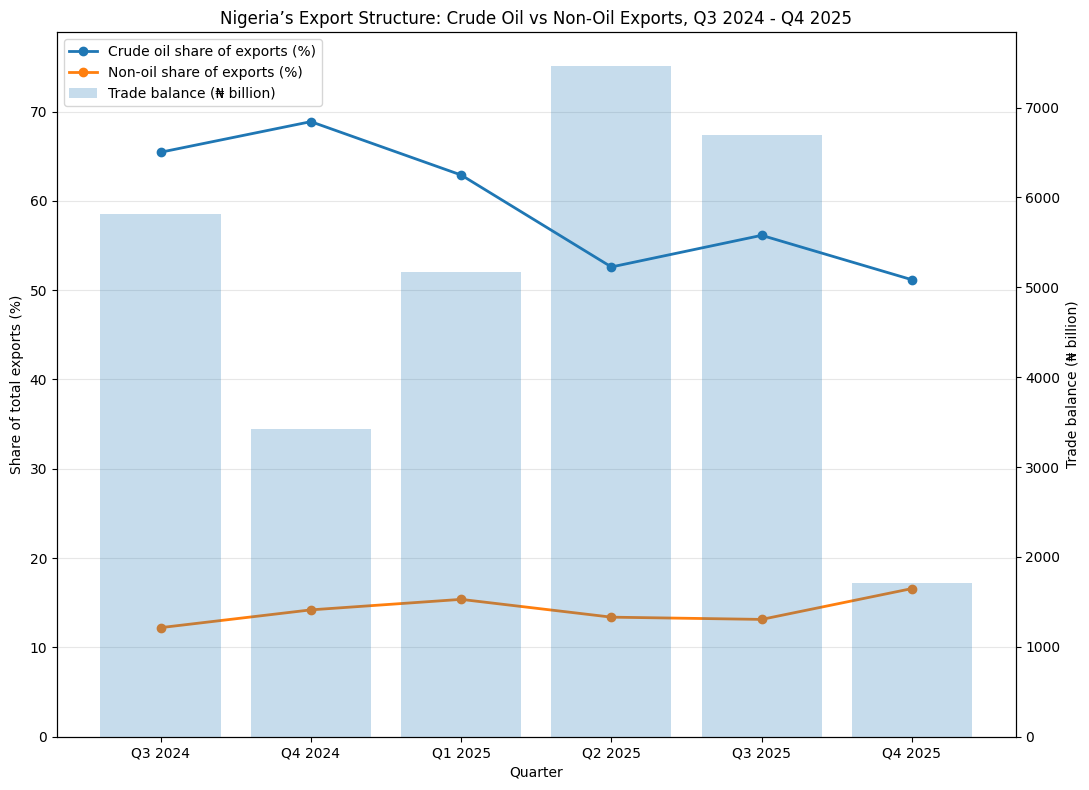

Chart saved to: /Users/desmondvi/Desktop/0022/nigeria_export_structure_q3_2024_q4_2025.png


In [9]:
output_chart = folder / "nigeria_export_structure_q3_2024_q4_2025.png"

fig, ax1 = plt.subplots(figsize=(11, 8))

ax1.plot(
    df["Quarter"],
    df["Crude_Oil_Share_of_Exports_pct"],
    marker="o",
    linewidth=2,
    label="Crude oil share of exports (%)",
)

ax1.plot(
    df["Quarter"],
    df["Non_Oil_Share_of_Exports_pct"],
    marker="o",
    linewidth=2,
    label="Non-oil share of exports (%)",
)

ax1.set_xlabel("Quarter")
ax1.set_ylabel("Share of total exports (%)")
ax1.set_ylim(0, max(df["Crude_Oil_Share_of_Exports_pct"]) + 10)

ax2 = ax1.twinx()

ax2.bar(
    df["Quarter"],
    df["Trade_Balance_NGN_billion"],
    alpha=0.25,
    label="Trade balance (₦ billion)",
)

ax2.set_ylabel("Trade balance (₦ billion)")

ax1.set_title(
    "Nigeria’s Export Structure: Crude Oil vs Non-Oil Exports, Q3 2024 - Q4 2025"
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left",
)

ax1.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(output_chart, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", output_chart)

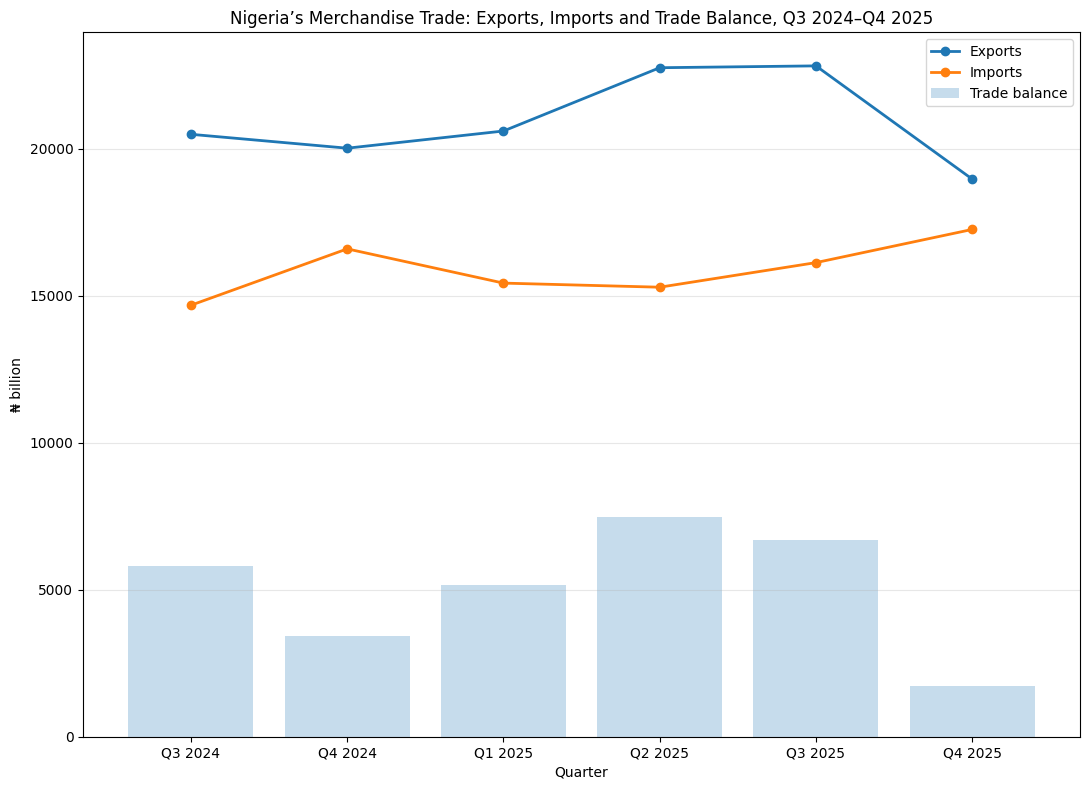

In [10]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.plot(
    df["Quarter"],
    df["Exports_NGN_billion"],
    marker="o",
    linewidth=2,
    label="Exports",
)

ax.plot(
    df["Quarter"],
    df["Imports_NGN_billion"],
    marker="o",
    linewidth=2,
    label="Imports",
)

ax.bar(
    df["Quarter"],
    df["Trade_Balance_NGN_billion"],
    alpha=0.25,
    label="Trade balance",
)

ax.set_xlabel("Quarter")
ax.set_ylabel("₦ billion")
ax.set_title("Nigeria’s Merchandise Trade: Exports, Imports and Trade Balance, Q3 2024–Q4 2025")

ax.legend()
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
output_table = folder / "nigeria_export_structure_summary_q3_2024_q4_2025.csv"

report_table.to_csv(output_table, index=False)

print("Table saved to:", output_table)

Table saved to: /Users/desmondvi/Desktop/0022/nigeria_export_structure_summary_q3_2024_q4_2025.csv
